# Lasso and Ridge Regression on GOOG
This notebook demonstrates how to use **Lasso** and **Ridge** regularization to predict next‑day returns of GOOG using engineered features.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 1. Download GOOG Daily Data

In [2]:
start = "2008-01-01"
end = "2018-01-01"

goog = yf.download("GOOG", start=start, end=end)
goog.head()

/var/folders/kh/tbjwzfys51n7nsxxq4q88gch0000gn/T/ipykernel_77119/1755970508.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  goog = yf.download("GOOG", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2008-01-02,16.916634,17.217346,16.732455,17.106246,172921733
2008-01-03,16.920092,16.957620,16.702582,16.918365,130587647
2008-01-04,16.220652,16.812200,16.171275,16.780845,215195594
2008-01-07,16.029312,16.351011,15.735515,16.145105,257096061
2008-01-08,15.595529,16.293733,15.578739,16.121897,214364490


## 2. Create Predictive Features

In [3]:
goog['returns'] = goog['Close'].pct_change()
goog['mean10'] = goog['Close'].rolling(10).mean()
goog['std10'] = goog['Close'].rolling(10).std()
goog['mean20'] = goog['Close'].rolling(20).mean()
goog['std20'] = goog['Close'].rolling(20).std()

X = goog[['returns', 'mean10', 'std10', 'mean20', 'std20']].dropna()
X.head()

Price,returns,mean10,std10,mean20,std20
Ticker,,,,,
Date,,,,,
2008-01-30,-0.004087,14.185343,0.610924,15.163619,1.132307
2008-01-31,0.029237,14.057825,0.496264,15.014386,1.084792
2008-02-01,-0.085770,13.848240,0.569698,14.805234,1.101157
2008-02-04,-0.039678,13.589450,0.660065,14.605784,1.189044
2008-02-05,0.022950,13.397987,0.667766,14.429937,1.226896


## 3. Target Variable: Next‑Day Returns

In [4]:
target = goog['returns'].shift(-1).loc[X.index]
target.head()

Date
2008-01-30    0.029237
2008-01-31   -0.085770
2008-02-01   -0.039678
2008-02-04    0.022950
2008-02-05   -0.010043
Name: returns, dtype: float64

## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, shuffle=False
)
X_train.shape, X_test.shape

((1999, 5), (500, 5))

## 5. Standardize Features (Required for Regularization)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Lasso Regression

In [7]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
lasso_preds = lasso.predict(X_test_scaled)

print("Lasso Coefficients:")
print(lasso.coef_)

Lasso Coefficients:
[-0. -0.  0. -0.  0.]


/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## 7. Ridge Regression

In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

print("Ridge Coefficients:")
print(ridge.coef_)

Ridge Coefficients:
[-0.00048813 -0.00196795  0.00029127  0.00170704  0.00012111]


/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## 8. Plot Predictions vs Actual

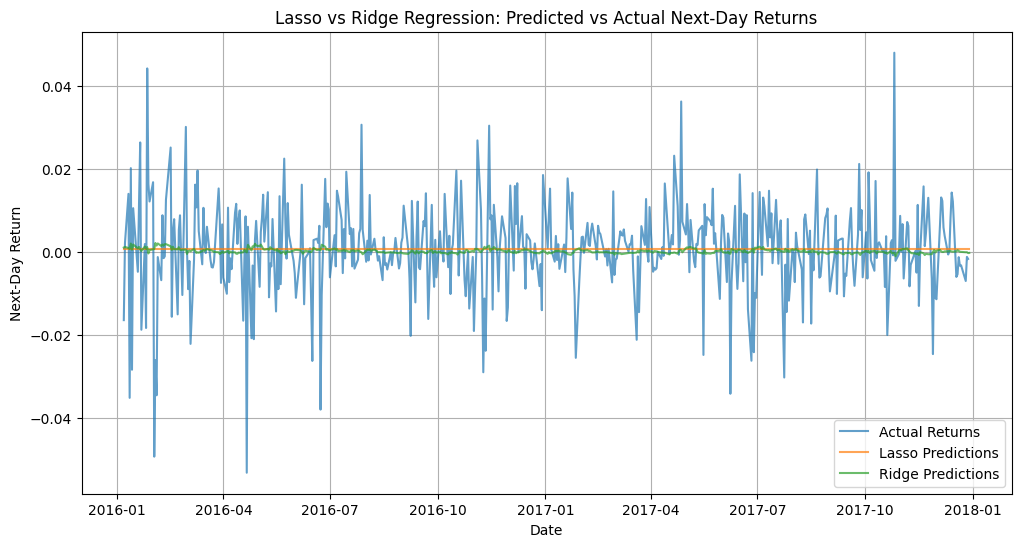

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual Returns', alpha=0.7)
plt.plot(y_test.index, lasso_preds, label='Lasso Predictions', alpha=0.7)
plt.plot(y_test.index, ridge_preds, label='Ridge Predictions', alpha=0.7)

plt.title('Lasso vs Ridge Regression: Predicted vs Actual Next-Day Returns')
plt.xlabel('Date')
plt.ylabel('Next-Day Return')
plt.legend()
plt.grid(True)
plt.show()